In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
df = pd.read_csv(r"C:\Users\Hp\Downloads\Telegram Desktop\healthcare-dataset-stroke-data.csv")
print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [5]:
df.isna().mean() *100

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64

In [6]:
df.duplicated().sum()

0

<AxesSubplot:ylabel='bmi'>

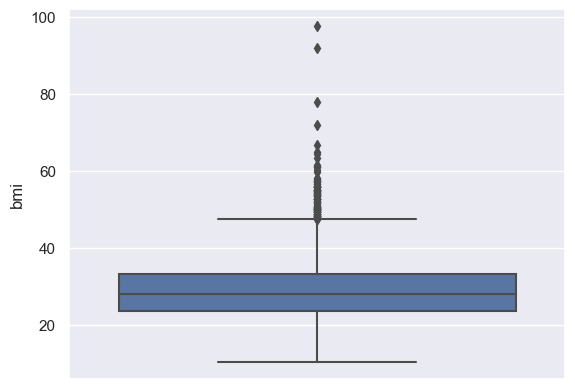

In [7]:
sns.boxplot(y = df['bmi'])

Since the bmi column has outliers,I would employ median imputation, I'll explore age category and get the median for each category to impute the null values

let's group our age into category and check

In [8]:
def agegroup(age):
    if age >= 0 and age < 18:
        return 'Teens'
    elif age >= 18 and age < 40:
        return 'Young adult'
    elif age >= 40 and age < 55:
        return 'Early midlife'
    elif age >= 55 and age < 65:
        return 'Late midlife'
    elif age >= 65 and age < 75:
        return 'Early Elderly'
    else:
        return 'Old age'

In [9]:
df['agegroup'] = df['age'].apply(agegroup)
print(df.shape)
df.head()

(5110, 13)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Late midlife
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age


In [10]:
bmi_median =df.groupby('agegroup')['bmi'].median().reset_index()
bmi_median


,agegroup,bmi
0,Early Elderly,29.55
1,Early midlife,30.30
2,Late midlife,30.40
3,Old age,28.00
4,Teens,19.90
5,Young adult,27.70


In [11]:
df['bmi'] = df['bmi'].fillna(df.groupby('agegroup')['bmi'].transform('median')) #filled missing value based on the median for each age group

In [12]:
df['bmi'].median()

28.1

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
 12  agegroup           5110 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 519.1+ KB


In [14]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
agegroup             0
dtype: int64

In [15]:
df['age']=df['age'].astype(int)

In [16]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age


In [17]:
#Explore other columns

In [18]:
df['ever_married'].value_counts()

Yes    3353
No     1757
Name: ever_married, dtype: int64

In [19]:
df['ever_married']= df['ever_married'].replace({'Yes':1,"No":0})

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   int32  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   int64  
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
 12  agegroup           5110 non-null   object 
dtypes: float64(2), int32(1), int64(5), object(5)
memory usage: 499.1+ KB


In [21]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61,0,0,1,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,31112,Male,80,0,1,1,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49,0,0,1,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,Old age


In [22]:
df['gender'].value_counts()

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [23]:
df[df['gender'].str.contains('Other')]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
3116,56156,Other,26,0,0,0,Private,Rural,143.33,22.4,formerly smoked,0,Young adult


The gender colum contains two dominant categories("male and female") and one observation with"other". This particular category represent only one record,therefore it has no meaningful statistical importance for our model

In [24]:
df = df[df['gender'] != 'Other'].reset_index(drop=True)


In [25]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61,0,0,1,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,31112,Male,80,0,1,1,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49,0,0,1,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,Old age
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,18234,Female,80,1,0,1,Private,Urban,83.75,28.0,never smoked,0,Old age
5105,44873,Female,81,0,0,1,Self-employed,Urban,125.20,40.0,never smoked,0,Old age
5106,19723,Female,35,0,0,1,Self-employed,Rural,82.99,30.6,never smoked,0,Young adult
5107,37544,Male,51,0,0,1,Private,Rural,166.29,25.6,formerly smoked,0,Early midlife


In [26]:
df['gender'].value_counts()

Female    2994
Male      2115
Name: gender, dtype: int64

In [27]:
df.shape

(5109, 13)

In [28]:
df['hypertension'].value_counts()

0    4611
1     498
Name: hypertension, dtype: int64

In [29]:
df['work_type'].value_counts()

Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: work_type, dtype: int64

In [30]:
df['Residence_type'].value_counts()

Urban    2596
Rural    2513
Name: Residence_type, dtype: int64

In [31]:
df['smoking_status'].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [32]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
agegroup             0
dtype: int64

<AxesSubplot:ylabel='avg_glucose_level'>

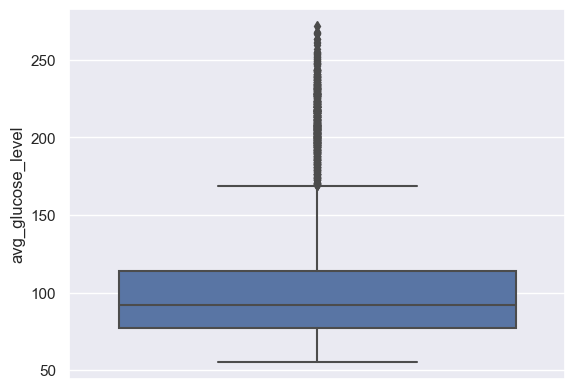

In [33]:
sns.boxplot(y = df['avg_glucose_level'])

### EDA

##### Is the Target Variable imbalanced?

In [34]:
df['stroke'].value_counts(normalize=True)

0    0.951262
1    0.048738
Name: stroke, dtype: float64

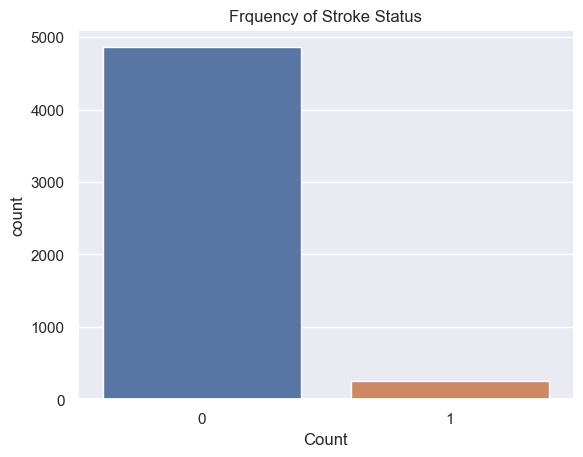

In [35]:
sns.countplot(x=df['stroke'])
plt.xlabel('Stroke')
plt.xlabel('Count')
plt.title('Frquency of Stroke Status');

y is greatly imbalanced

In [36]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61,0,0,1,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,31112,Male,80,0,1,1,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49,0,0,1,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,Old age


##### Distribution of target variable and age

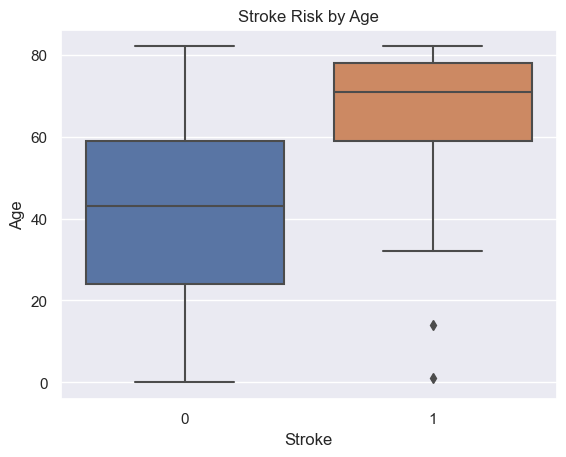

In [37]:
sns.boxplot(x='stroke',y ='age',data = df)
plt.xlabel('Stroke')
plt.ylabel('Age')
plt.title('Stroke Risk by Age');

In [38]:
df.groupby('stroke')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4860.0,41.962963,22.314896,0.0,24.0,43.0,59.0,82.0
1,249.0,67.726908,12.734166,1.0,59.0,71.0,78.0,82.0


Stroke is predominant in ages between 35-80 with outliers

In [39]:
df[(df['stroke'] == 1) & (df['age']< 35)]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
162,69768,Female,1,0,0,0,children,Urban,70.37,19.9,Unknown,1,Teens
182,39912,Female,32,0,0,1,Private,Rural,76.13,29.9,smokes,1,Young adult
245,49669,Female,14,0,0,0,children,Rural,57.93,30.9,Unknown,1,Teens


Stroke patients are significantly older than non-stroke patients.

The presence of stroke cases at ages 1 and 14 likely represents:
- Rare pediatric stroke cases
 


Aggregate by worktype

In [40]:
work_pivot = pd.pivot_table(df,index='work_type',values='stroke',aggfunc=np.mean)
work_pivot.sort_values(by='stroke')

,stroke
work_type,
Never_worked,0.000000
children,0.002911
Govt_job,0.050228
Private,0.050958
Self-employed,0.079365


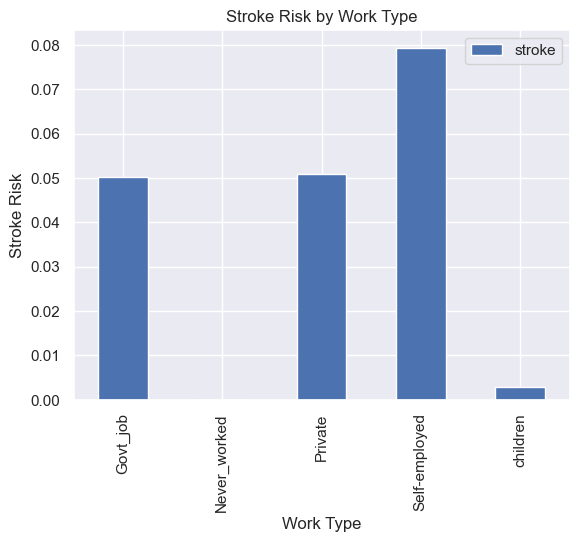

In [41]:
work_pivot.plot(kind='bar')
plt.xlabel('Work Type')
plt.ylabel('Stroke Risk')
plt.title('Stroke Risk by Work Type');

Self-employed individuals show slightly higher stroke incidence.

In [42]:
df.select_dtypes('object').nunique() #checks for high/low cardinalty categorical feature

gender            2
work_type         5
Residence_type    2
smoking_status    4
agegroup          6
dtype: int64

In [43]:
df.select_dtypes('number').nunique()

id                   5109
age                    83
hypertension            2
heart_disease           2
ever_married            2
avg_glucose_level    3978
bmi                   419
stroke                  2
dtype: int64

In [44]:
#drop high cardinal features
df.drop(columns='id',inplace=True)

In [45]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,Male,67,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,Female,61,0,0,1,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,Male,80,0,1,1,Private,Rural,105.92,32.5,never smoked,1,Old age
3,Female,49,0,0,1,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,Female,79,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,Old age
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,Female,80,1,0,1,Private,Urban,83.75,28.0,never smoked,0,Old age
5105,Female,81,0,0,1,Self-employed,Urban,125.20,40.0,never smoked,0,Old age
5106,Female,35,0,0,1,Self-employed,Rural,82.99,30.6,never smoked,0,Young adult
5107,Male,51,0,0,1,Private,Rural,166.29,25.6,formerly smoked,0,Early midlife


##### Does stroke differ by gender?

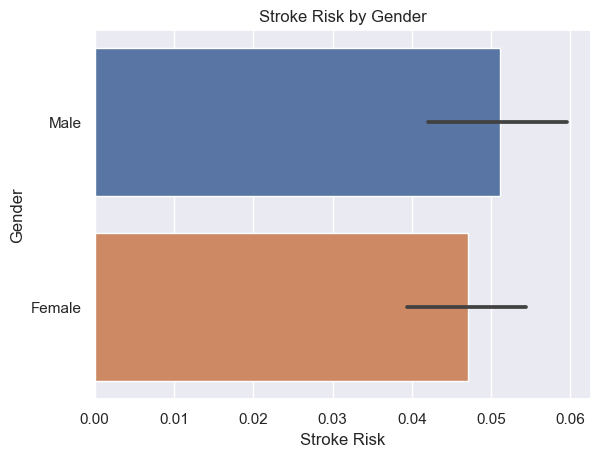

In [46]:
sns.barplot(data=df, x="stroke", y="gender",orient='h')
plt.ylabel('Gender')
plt.xlabel('Stroke Risk')
plt.title('Stroke Risk by Gender');

Stroke incidence is slightly higher in males, but the difference is marginal.

In [47]:
df.to_csv('stroke_data.csv')

In [48]:
df['age']

0       67
1       61
2       80
3       49
4       79
        ..
5104    80
5105    81
5106    35
5107    51
5108    44
Name: age, Length: 5109, dtype: int32

##### At what age does stroke frequency increase sharply?

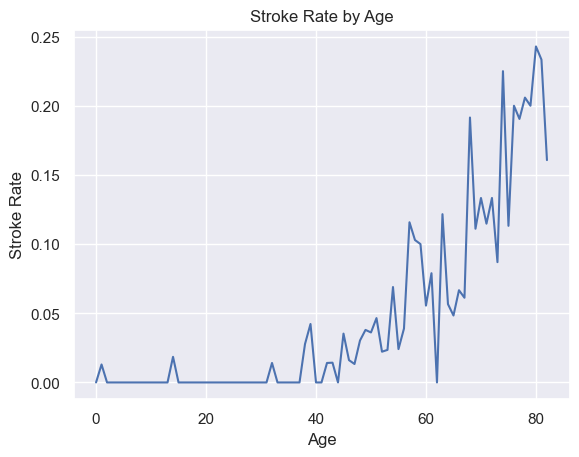

In [49]:
stroke_rate = df.groupby('age')['stroke'].mean()

# Plot
plt.figure()
plt.plot(stroke_rate.index, stroke_rate.values)
plt.xlabel('Age')
plt.ylabel('Stroke Rate')
plt.title('Stroke Rate by Age');

## Stroke Rate by Age

The stroke rate increases progressively with age, with a noticeable acceleration after approximately **55–60 years**.

### Key Observations:

- Stroke incidence is near zero below age 40.
- A gradual increase begins around 45–50.
- A sharp rise occurs after 60.
- The highest stroke rates are observed in individuals aged 70+.
- Variability at very young ages (e.g., 1–14 years) likely reflects rare cases.

### Interpretation:

The curve shows a clear non-linear upward trend, indicating that stroke risk accelerates in later adulthood rather than increasing uniformly.


##### What is the BMI distribution ?

Is BMI higher in stroke patients?

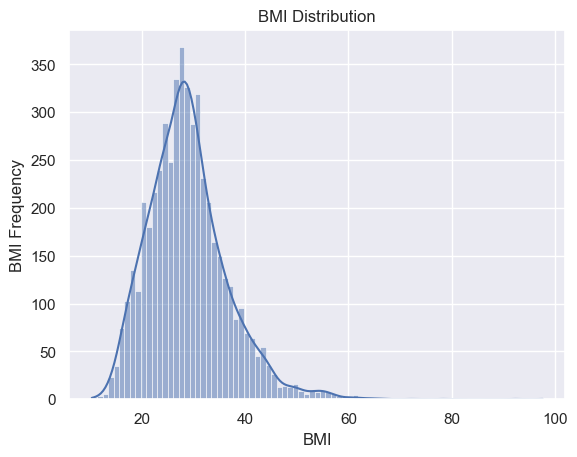

In [50]:
import seaborn as sns
sns.histplot(df['bmi'],kde=True)
plt.xlabel('BMI')
plt.ylabel('BMI Frequency')
plt.title('BMI Distribution');


The BMI distribution is right-skewed.

### Key Observations:

- Most individuals cluster between BMI 20 and 35.
- The peak density lies around 27–30.
- A long right tail extends beyond BMI 40.
- Extreme values exist above 50 but are rare.

### Interpretation:

The right skew indicates presence of higher-BMI individuals, which may influence linear models.  
Median BMI is more representative than the mean due to skewness.



In [53]:
df.groupby('stroke')['bmi'].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4860.0,28.800556,7.799142,10.3,23.5,28.00,32.8,97.6
1,249.0,30.199398,5.873662,16.9,27.0,29.55,32.5,56.6


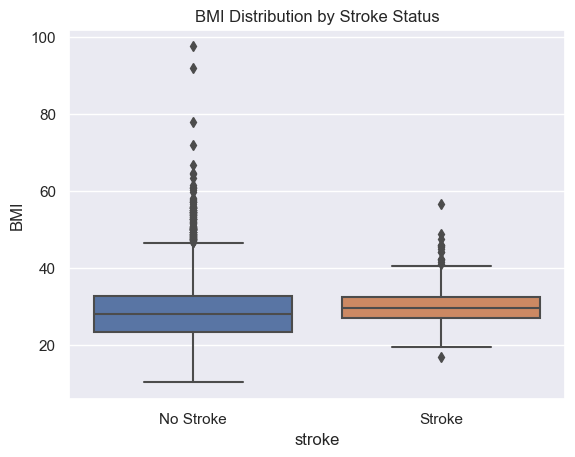

In [54]:
sns.boxplot(x='stroke',y ='bmi',data = df)
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.ylabel('BMI')
plt.title('BMI Distribution by Stroke Status')
plt.show()

Stroke patients show slightly higher BMI values.

However, the difference is modest, and the distributions overlap substantially.

When combining findings:

- Stroke risk rises sharply with age.
- BMI shows modest elevation in stroke patients.
- The impact of BMI likely interacts with age and cardiovascular conditions.

This suggests stroke risk is primarily age-driven, with metabolic and cardiovascular factors acting as amplifiers.

In [55]:
df.groupby('stroke')['avg_glucose_level'].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4860.0,104.787584,43.847095,55.12,77.12,91.465,112.80,267.76
1,249.0,132.544739,61.921056,56.11,79.79,105.220,196.71,271.74


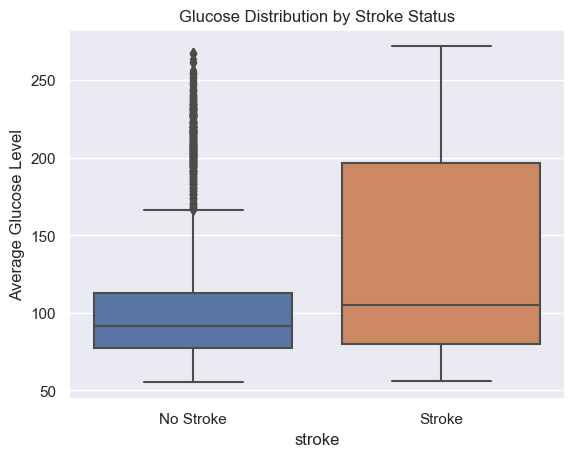

In [108]:
sns.boxplot(x='stroke',y ='avg_glucose_level',data = df)
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.ylabel('Average Glucose Level')
plt.title('Glucose Distribution by Stroke Status')
plt.show()

Stroke patients have higher glucose levels, especially at the upper quartile.

The large difference in mean (104.7 vs 132.5) and wide upper IQR suggests:
- Hyperglycemia is strongly associated with stroke.

Average glucose level is a strong predictive feature.


##### Do heart disease patients have higher stroke rates?

In [56]:
stroke_rate_hd = df.groupby('heart_disease')['stroke'].mean()
print(stroke_rate_hd)

heart_disease
0    0.041796
1    0.170290
Name: stroke, dtype: float64


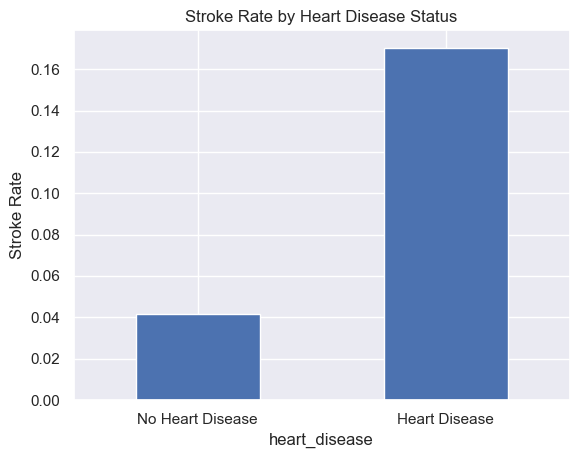

In [57]:
stroke_rate_hd.plot(kind='bar')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'], rotation=0)
plt.ylabel('Stroke Rate')
plt.title('Stroke Rate by Heart Disease Status')
plt.show()

Individuals with heart disease have over **4× higher stroke incidence**.

This is one of the strongest associations observed in the dataset.

Heart disease is a major risk factor and likely a top predictive feature.

##### What is the distribution of smoking status?

In [58]:
df['smoking_status'].value_counts(normalize=True)

never smoked       0.370327
Unknown            0.302212
formerly smoked    0.173028
smokes             0.154433
Name: smoking_status, dtype: float64

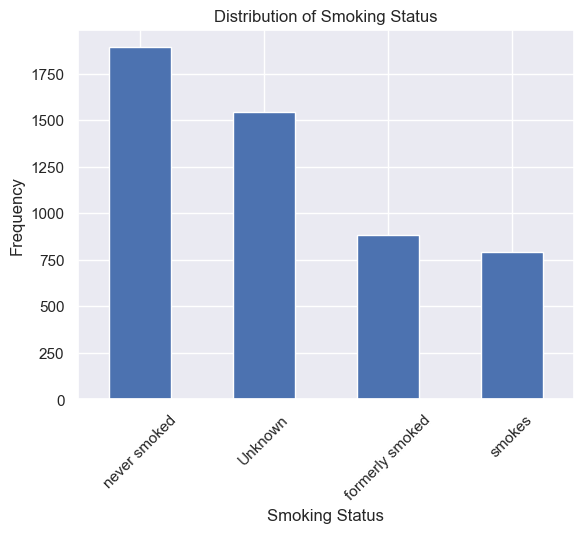

In [59]:
smoking_counts = df['smoking_status'].value_counts()

smoking_counts.plot(kind='bar')
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')
plt.title('Distribution of Smoking Status')
plt.xticks(rotation=45)
plt.show()

In [60]:
stroke_by_smoking = df.groupby('smoking_status')['stroke'].mean().sort_values(ascending=False)
stroke_by_smoking

smoking_status
formerly smoked    0.079186
smokes             0.053232
never smoked       0.047569
Unknown            0.030440
Name: stroke, dtype: float64

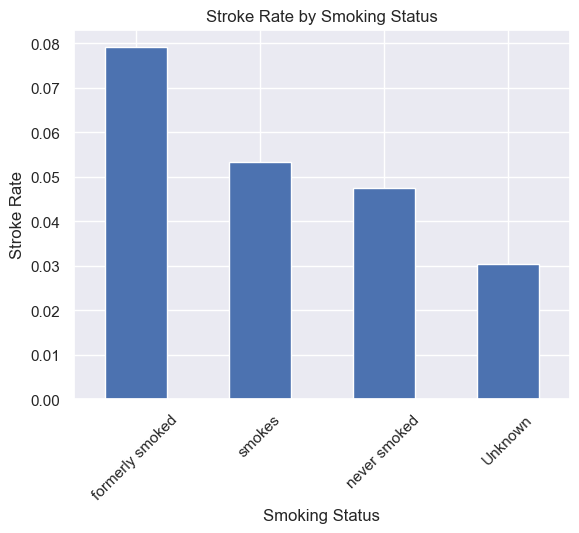

In [61]:
stroke_by_smoking.plot(kind='bar')
plt.xlabel('Smoking Status')
plt.ylabel('Stroke Rate')
plt.title('Stroke Rate by Smoking Status')
plt.xticks(rotation=45);


Former smokers exhibit the highest stroke incidence.
This likely reflects age confounding (former smokers tend to be older).

Current smokers show moderately elevated risk compared to never smokers.
 
Smoking is associated with increased stroke risk.

##### Which numerical features are strongly correlated?

Is there multicollinearity?

In [62]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level',
       'bmi', 'stroke'],
      dtype='object')

In [63]:
corr_matrix = df[num_cols].corr()
corr_matrix

,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke
hypertension,1.000000,0.108292,0.164187,0.174540,0.161863,0.127891
heart_disease,0.108292,1.000000,0.114601,0.161907,0.040424,0.134905
ever_married,0.164187,0.114601,1.000000,0.155329,0.342381,0.108299
avg_glucose_level,0.174540,0.161907,0.155329,1.000000,0.170499,0.131991
bmi,0.161863,0.040424,0.342381,0.170499,1.000000,0.039010
stroke,0.127891,0.134905,0.108299,0.131991,0.039010,1.000000


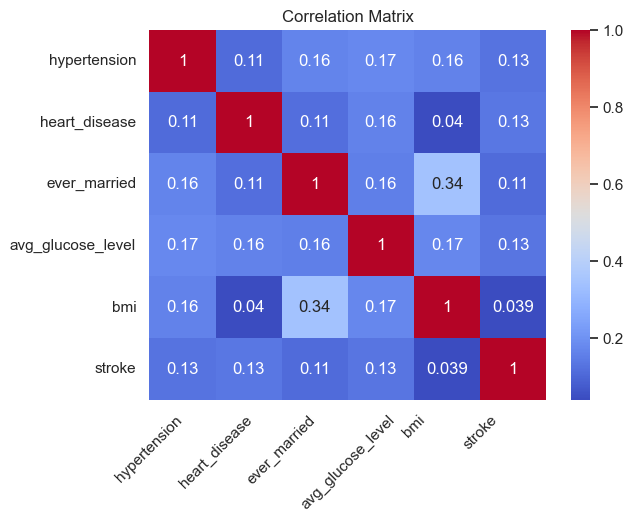

In [64]:
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.title('Correlation Matrix');

In [146]:
df.groupby('agegroup')['hypertension'].mean().sort_values()

agegroup
Teens            0.001168
Young adult      0.027418
Early midlife    0.098191
Late midlife     0.155585
Early Elderly    0.208251
Old age          0.239382
Name: hypertension, dtype: float64

##### Does hypertension prevalence increase with age group?

At which age group does hypertension rise sharply?

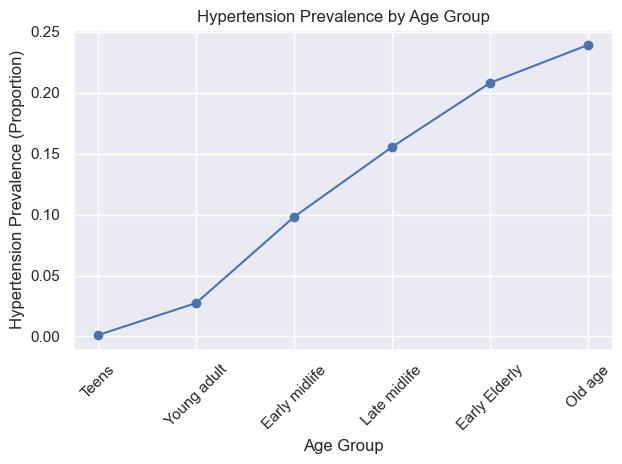

agegroup
Teens            0.001168
Young adult      0.027418
Early midlife    0.098191
Late midlife     0.155585
Early Elderly    0.208251
Old age          0.239382
Name: hypertension, dtype: float64

In [147]:
# Calculate hypertension prevalence per age group
htn_by_age = df.groupby('agegroup')['hypertension'].mean().sort_values()

# Plot
plt.figure()
plt.plot(htn_by_age.index.astype(str), htn_by_age.values, marker='o')
plt.xlabel("Age Group")
plt.ylabel("Hypertension Prevalence (Proportion)")
plt.title("Hypertension Prevalence by Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display numeric values
htn_by_age

##### What is the stroke rate among hypertensive patients within each age group?

In [177]:
stroke_by_group = (df.groupby(['agegroup', 'hypertension'])['stroke'].mean().unstack())
stroke_by_group.sort_index()
stroke_by_group[0]

agegroup
Teens            0.002339
Young adult      0.003915
Early midlife    0.021012
Late midlife     0.070866
Early Elderly    0.091811
Old age          0.182741
Name: 0, dtype: float64

In [176]:
age_order = ["Teens", "Young adult", "Early midlife", "Late midlife", "Early Elderly", "Old age"]

# Convert to categorical with order
df['agegroup'] = pd.Categorical(df['agegroup'], categories=age_order, ordered=True)

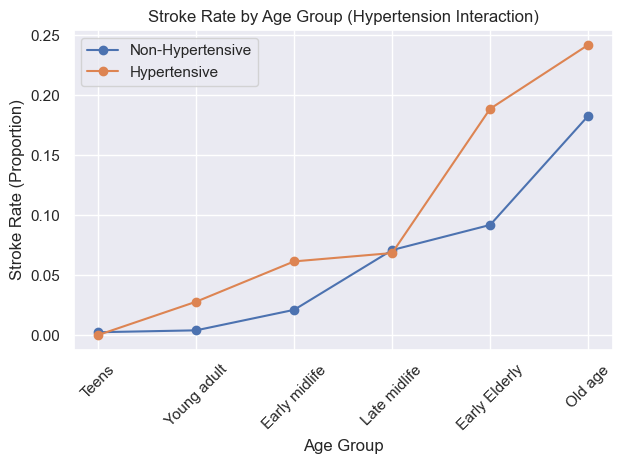

In [178]:
# Compute stroke rate by age group and hypertension status
stroke_by_group = (df.groupby(['agegroup', 'hypertension'])['stroke'].mean().unstack())

# Plot both lines on a single graph
plt.figure()

plt.plot(stroke_by_group.index.astype(str),
         stroke_by_group[0],
         marker='o',
         label='Non-Hypertensive')

plt.plot(stroke_by_group.index.astype(str),
         stroke_by_group[1],
         marker='o',
         label='Hypertensive')

plt.xlabel("Age Group")
plt.ylabel("Stroke Rate (Proportion)")
plt.title("Stroke Rate by Age Group (Hypertension Interaction)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


##### Is hypertension more common among married individuals?

In [183]:
htn_by_marital = df.groupby('ever_married')['hypertension'].mean()

print(htn_by_marital)

ever_married
0    0.030182
1    0.132717
Name: hypertension, dtype: float64


ever_married          0         1
agegroup                         
Teens          0.001168       NaN
Young adult    0.017134  0.037258
Early midlife  0.092437  0.098848
Late midlife   0.196078  0.152639
Early Elderly  0.212121  0.207983
Old age        0.236364  0.239741
ever_married
0    0.030182
1    0.132717
Name: hypertension, dtype: float64


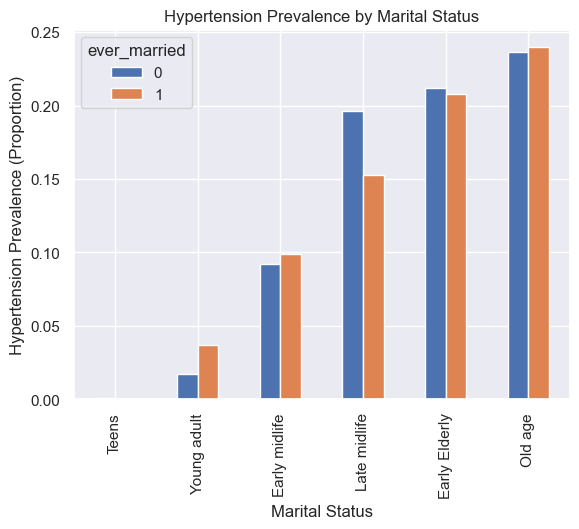

In [182]:
# Hypertension prevalence by age group and marital status
htn_by_age_marital = df.groupby(['agegroup', 'ever_married'])['hypertension'].mean().unstack()

print(htn_by_age_marital.sort_index())


# visualize
htn_by_age_marital.plot(kind='bar')
plt.xlabel("Marital Status")
plt.ylabel("Hypertension Prevalence (Proportion)")
plt.title("Hypertension Prevalence by Marital Status")
plt.show()


Married individuals tend to be older, and hypertension prevalence rises sharply with age (especially after 55). So  hypertension is more common among married people, it’s likely driven by age rather than marriage itself. 

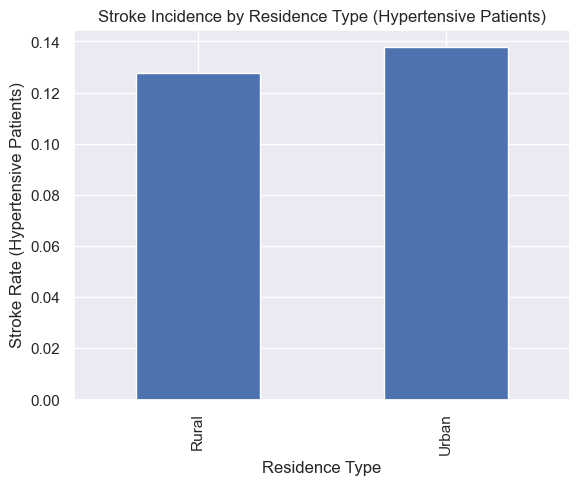

In [72]:
# Filter hypertensive patients
hypertensive_df = df[df['hypertension'] == 1]

# Compute stroke incidence by residence type
stroke_by_residence_htn = hypertensive_df.groupby('Residence_type')['stroke'].mean()

#visualize
stroke_by_residence_htn.plot(kind='bar')
plt.xlabel("Residence Type")
plt.ylabel("Stroke Rate (Hypertensive Patients)")
plt.title("Stroke Incidence by Residence Type (Hypertensive Patients)")
plt.show()


Is there an interaction: Residence, Hypertension and Stroke?

hypertension           0         1
Residence_type                    
Rural           0.036251  0.127490
Urban           0.042997  0.137652


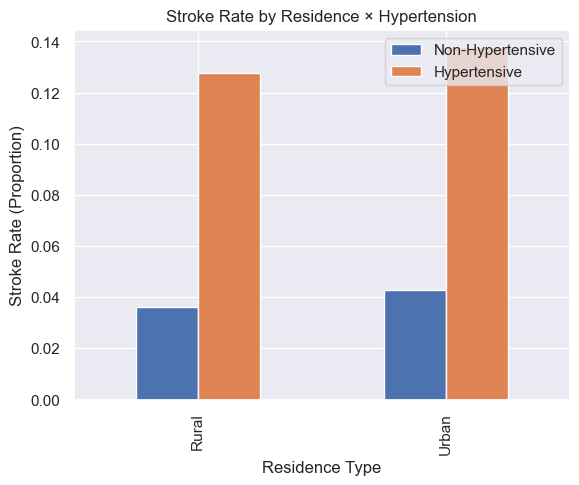

In [73]:
# Stroke incidence by residence type and hypertension
stroke_res_htn = df.groupby(['Residence_type','hypertension'])['stroke'].mean().unstack()

print(stroke_res_htn)

# Visualize
stroke_res_htn.plot(kind='bar')
plt.xlabel("Residence Type")
plt.ylabel("Stroke Rate (Proportion)")
plt.title("Stroke Rate by Residence × Hypertension")
plt.legend(["Non-Hypertensive","Hypertensive"])
plt.show()


Hypertensive patients in Urban areas show higher stroke incidence than hypertensive patients in Rural areas, it suggests lifestyle, stress, or healthcare access may amplify the risk.

### Insights

Strongest Predictors (Based on EDA):
1. Age
2. Heart Disease
3. Average Glucose Level
4. Hypertension

Moderate Predictors:
4. BMI
5. Smoking Status

Weak Predictors:
6. Gender
7. Work Type


### Final Conclusion

Stroke incidence in this dataset is primarily driven by:

- Advanced age
- Cardiovascular disease presence
- Elevated glucose levels
- Hyperntension

Lifestyle and demographic factors contribute but appear secondary to clinical variables.
